In [1]:
%cd ../..

/mnt/batch/tasks/shared/LS_root/mounts/clusters/jeffrey-uso9-03-dev-ci01/code/Users/jeffrey.tackes/ModernTS_2E


In [2]:
import os
import shutil
import json

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_white"

from pathlib import Path

from tqdm.autonotebook import tqdm
from IPython.display import display, HTML
# %load_ext autoreload
# %autoreload 2
np.random.seed(42)
tqdm.pandas()

from statsforecast import StatsForecast
from neuralforecast import NeuralForecast
from neuralforecast.models import TFT
from neuralforecast.auto import AutoTFT
from neuralforecast.losses.pytorch import MAE
from neuralforecast.losses.pytorch import MQLoss
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mse, mase
from functools import partial

from ray import tune
from ray.tune.search.hyperopt import HyperOptSearch


import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

/tmp/ipykernel_12859/2082162911.py:15: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
2025-07-02 03:49:28,452	INFO util.py:154 -- Outdated packages:
  ipywidgets==7.8.5 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-07-02 03:49:28,551	INFO util.py:154 -- Outdated packages:
  ipywidgets==7.8.5 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich 

In [3]:
TRAIN_SUBSAMPLE = True  # Trains a subsample of IDs to improve run speed
RETUNE = False  # if false, will use pre-trained hyperparameters when generating the AUTO NeuralForecast

In [4]:
preprocessed = Path("data/london_smart_meters/preprocessed")
output = Path("data/london_smart_meters/output")
try:
    #Reading the missing value imputed and train test split data
    train_df = pd.read_parquet(preprocessed/"selected_blocks_train_missing_imputed_feature_engg.parquet")
    # Read in the Validation dataset as test_df so that we predict on it
    test_df = pd.read_parquet(preprocessed/"selected_blocks_val_missing_imputed_feature_engg.parquet")
    # test_df = pd.read_parquet(preprocessed/"selected_blocks_test_missing_imputed_feature_engg.parquet")
except FileNotFoundError:
    display(HTML("""
    <div class="alert alert-block alert-warning">
    <b>Warning!</b> File not found. Please make sure you have run 01-Feature Engineering.ipynb in Chapter06
    </div>
    """))

In [5]:
train_df.head(2)

,timestamp,LCLid,energy_consumption,frequency,series_length,stdorToU,Acorn,Acorn_grouped,file,holidays,...,timestamp_Minute_sin_1,timestamp_Minute_sin_2,timestamp_Minute_sin_3,timestamp_Minute_sin_4,timestamp_Minute_sin_5,timestamp_Minute_cos_1,timestamp_Minute_cos_2,timestamp_Minute_cos_3,timestamp_Minute_cos_4,timestamp_Minute_cos_5
0,2012-01-01 00:00:00,MAC000061,0.114,30min,37872,Std,ACORN-Q,Adversity,block_96,NO_HOLIDAY,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.0,1.0,1.0,1.0,1.0
1,2012-01-01 00:30:00,MAC000061,0.113,30min,37872,Std,ACORN-Q,Adversity,block_96,NO_HOLIDAY,...,5.665539e-16,-1.133108e-15,2.143751e-15,-2.266215e-15,6.123234e-16,-1.0,1.0,-1.0,1.0,-1.0


In [6]:
print("Total # of IDs Pre-Sampling: ", len(train_df.LCLid.unique()))

Total # of IDs Pre-Sampling:  150


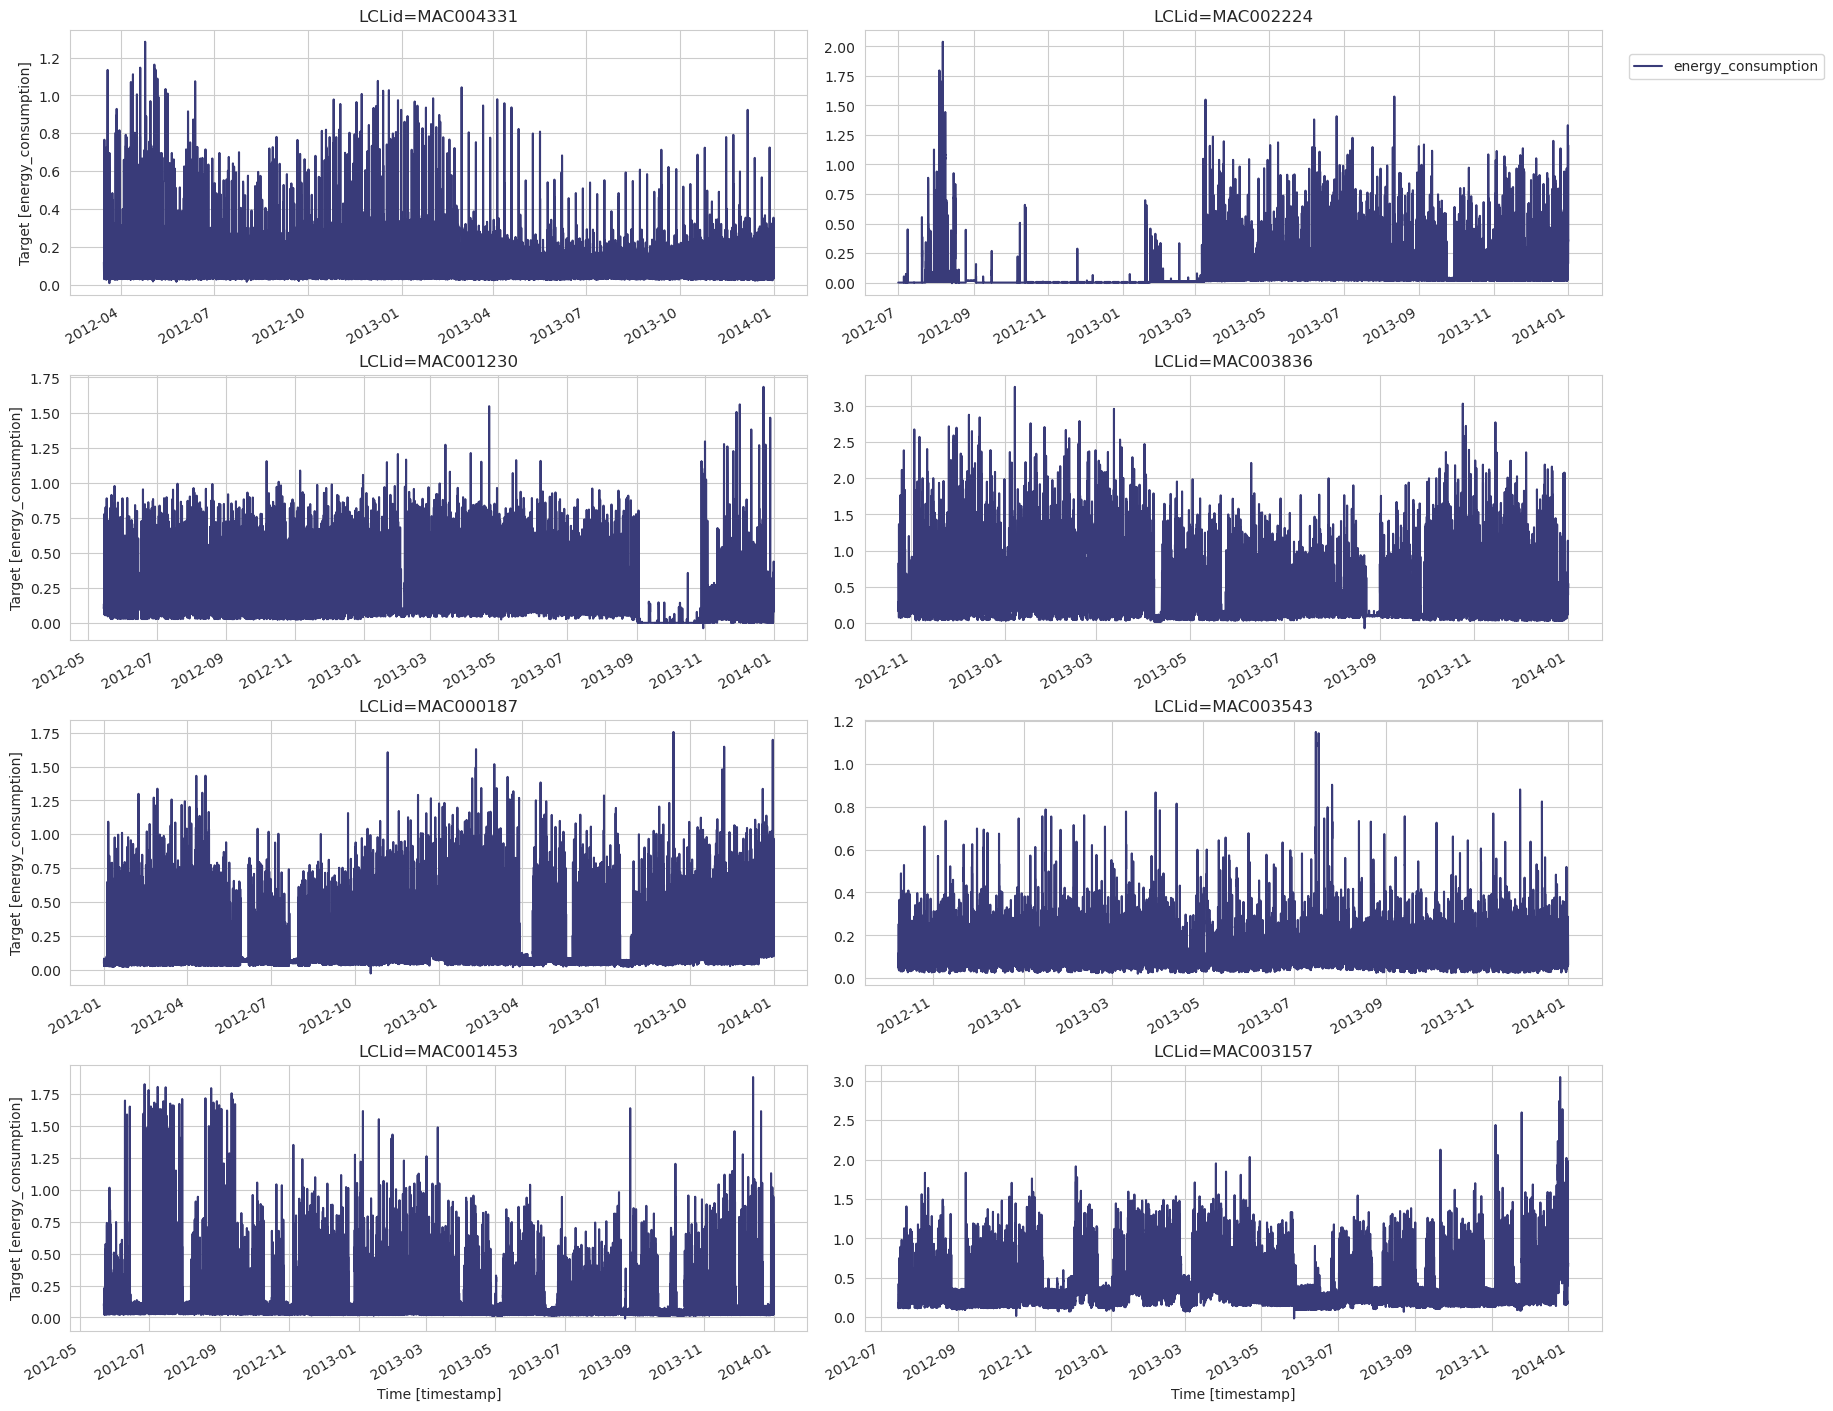

In [7]:
StatsForecast.plot(train_df, engine='matplotlib', id_col='LCLid',time_col= 'timestamp', target_col='energy_consumption')

In [8]:
# To run on smaller set of data for daster iteration.
if TRAIN_SUBSAMPLE:
    print("sub sampling")
    SAMPLE = 10
    sampled_LCLids = pd.Series(train_df.LCLid.unique().remove_unused_categories().categories).sample(SAMPLE, random_state=99).tolist()
    train_df = train_df.loc[train_df.LCLid.isin(sampled_LCLids)]
    test_df = test_df.loc[test_df.LCLid.isin(sampled_LCLids)]

sub sampling


In [9]:
print("Total # of IDs Post Sampling: ", len(train_df.LCLid.unique()))

Total # of IDs Post Sampling:  10


## Train, Validation, Test Set

In [10]:
print("Training Min Date: ", train_df.timestamp.min(), 
      "\nTraining Max Date: ", train_df.timestamp.max(), 
      "\nTesting Min Date: ", test_df.timestamp.min(),
      "\nTesting Max Date: ", test_df.timestamp.max()
)

Training Min Date:  2012-01-01 00:00:00 
Training Max Date:  2013-12-31 23:30:00 
Testing Min Date:  2014-01-01 00:00:00 
Testing Max Date:  2014-01-31 23:30:00


In [11]:
#Keeping 1 days aside as a validation set
cutoff = train_df.timestamp.max() - pd.Timedelta(1, "D")

validation_df = train_df[(train_df.timestamp>cutoff)].reset_index(drop=True) # validation prediction set
training_df = train_df[(train_df.timestamp<=cutoff)].reset_index(drop=True) # training set used for validation set

print(f"Train Max: {training_df.timestamp.max()} \nValidation Min: {validation_df.timestamp.min()} \nValidation Max: {validation_df.timestamp.max()}")
print(f"Validation Horizon: {len(validation_df.timestamp.unique())}")


Train Max: 2013-12-30 23:30:00 
Validation Min: 2013-12-31 00:00:00 
Validation Max: 2013-12-31 23:30:00
Validation Horizon: 48


##### Define Validation model parameters

In [12]:
h = 48
max_steps = 10

## Training TFT Model

In [13]:
model_untuned = [TFT(h=h,  input_size = 48*7,              
                max_steps=max_steps)]

model_untuned = NeuralForecast(models=model_untuned, freq='30min')
model_untuned.fit(training_df[['LCLid','timestamp','energy_consumption']], id_col = 'LCLid',time_col = 'timestamp',target_col='energy_consumption')

Seed set to 1
/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")
/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/neuralforecast/common/_base_model.py:345: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                    | Type                     | Params | Mode 
---------------------------------------------------------------------

Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_steps=10` reached.


In [14]:
# Get Predictions for validation
pred_df =  model_untuned.predict(futr_df=validation_df[['LCLid','timestamp','energy_consumption']]).reset_index()
pred_df = pred_df.merge(validation_df[['LCLid','timestamp','energy_consumption']], on=['LCLid','timestamp'], how='left')
pred_df.head()

/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                                                                                 …

/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/neuralforecast/core.py:209: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


,LCLid,timestamp,TFT,energy_consumption
0,MAC000126,2013-12-31 00:00:00,0.092376,0.093
1,MAC000126,2013-12-31 00:30:00,0.091075,0.109
2,MAC000126,2013-12-31 01:00:00,0.089757,0.082
3,MAC000126,2013-12-31 01:30:00,0.088532,0.067
4,MAC000126,2013-12-31 02:00:00,0.087501,0.043


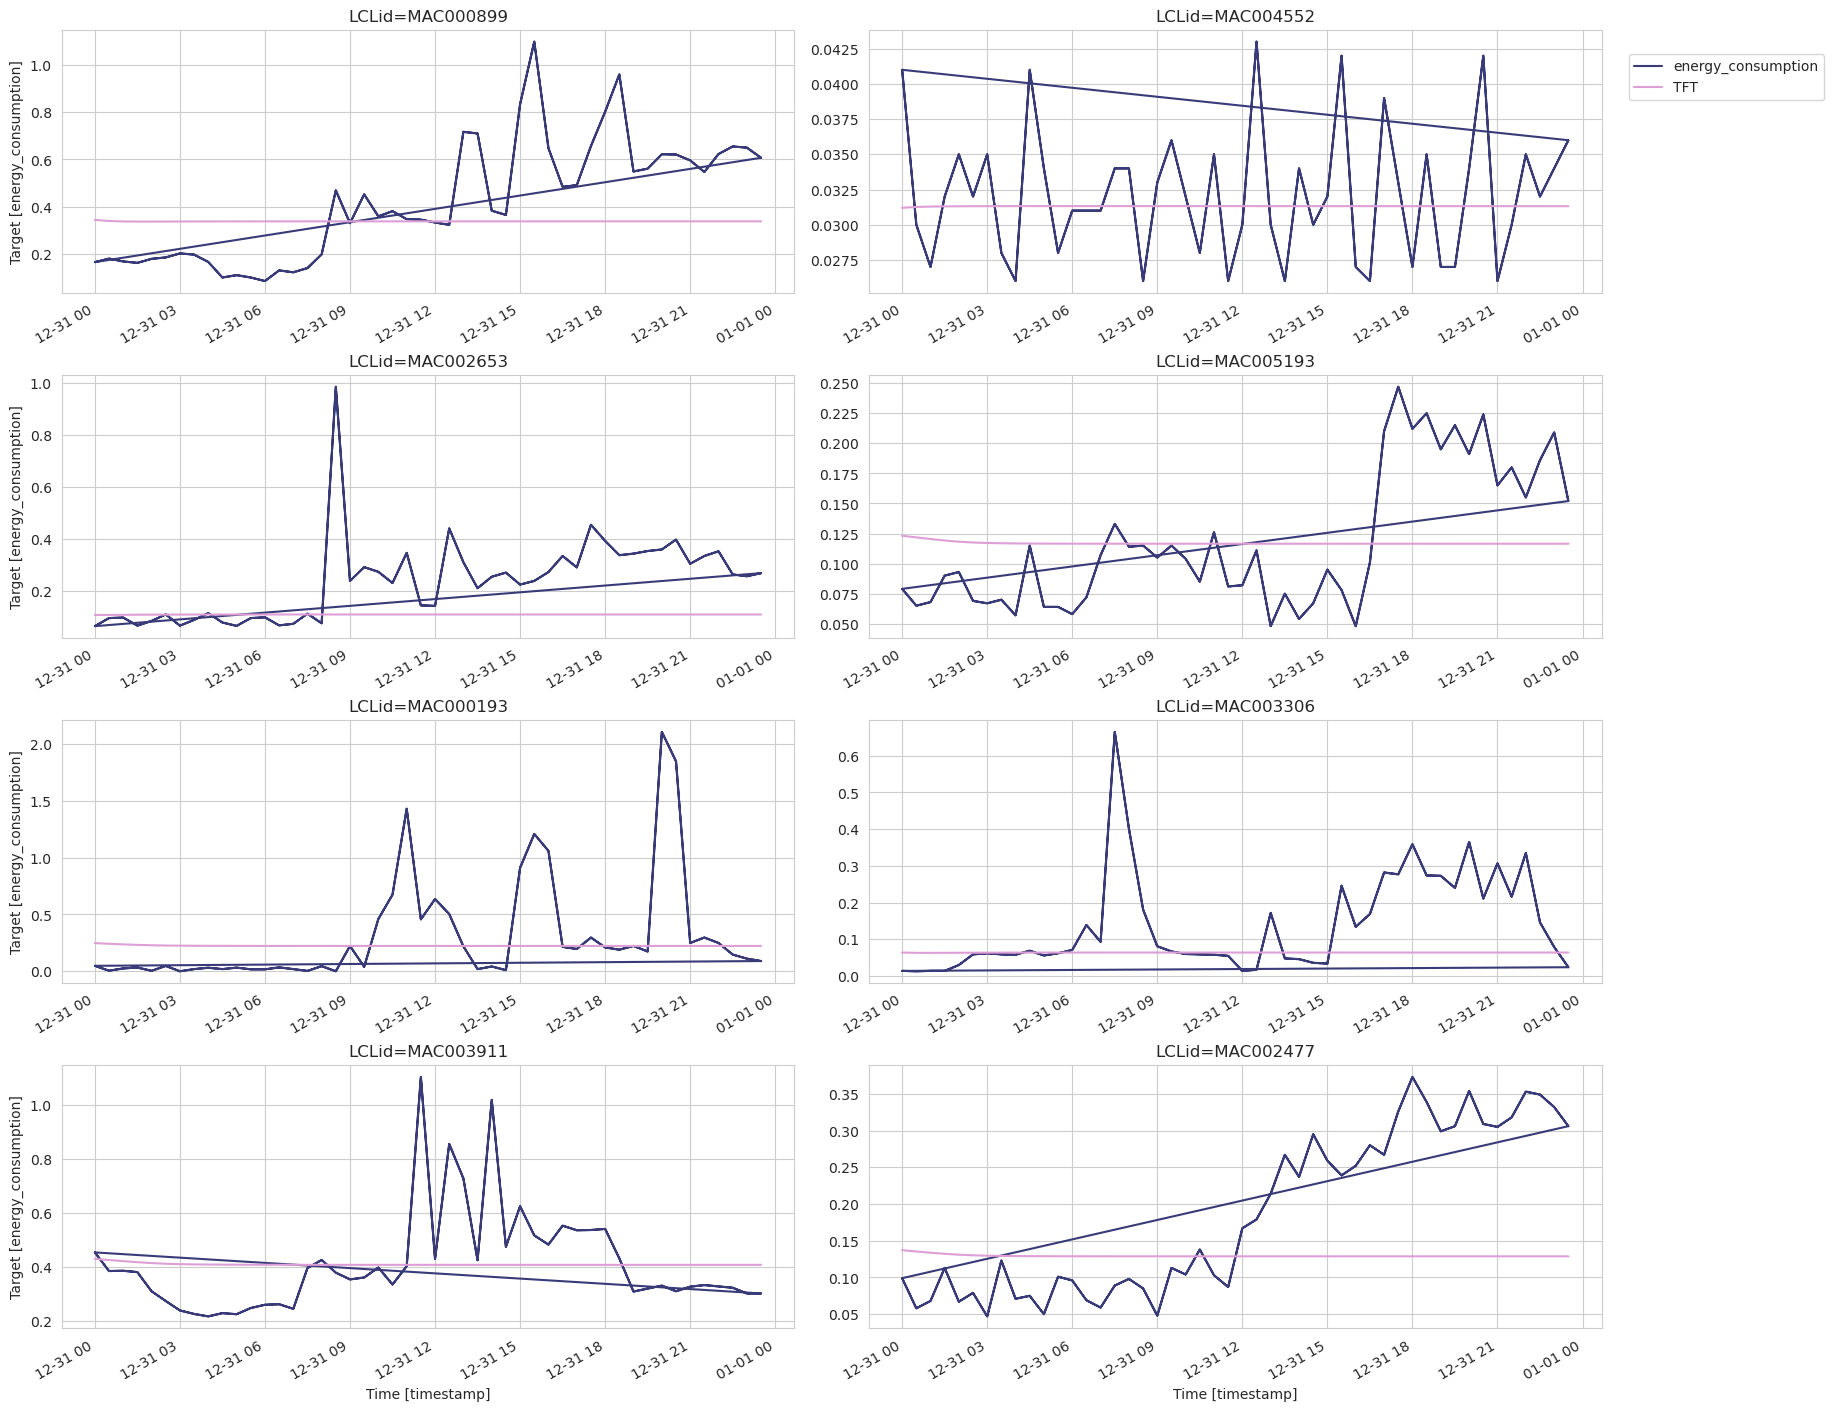

In [15]:
#visualize results
StatsForecast.plot(validation_df[['LCLid','timestamp','energy_consumption']], 
                   pred_df, engine='matplotlib', 
                   id_col='LCLid',
                   time_col= 'timestamp', 
                   target_col='energy_consumption',
                   models=['TFT'])

#### Evaluate TFT forecast

In [16]:
fcst_mase = partial(mase, seasonality=48)

# Get metrics for individual LCLid's
TFT_metrics = evaluate(pred_df, 
        metrics=[rmse, mae, mse, fcst_mase],  
        train_df = train_df[['timestamp', 'LCLid', 'energy_consumption']],      
        id_col = 'LCLid',
        time_col = 'timestamp',
        target_col = 'energy_consumption'
        )

# Get aggregated metrics for across all LCLid's by model
TFT_metrics_agg = evaluate(pred_df, 
        metrics=[rmse, mae, mse, fcst_mase],  
        train_df = train_df[['timestamp', 'LCLid', 'energy_consumption']],      
        id_col = 'LCLid',
        time_col = 'timestamp',
        target_col = 'energy_consumption',
        agg_fn='mean'
        )

In [17]:
TFT_metrics_agg

,metric,TFT
0,rmse,0.163063
1,mae,0.113527
2,mse,0.043618
3,mase,1.020657


## TFT Tuned
Since hyperparameters are key to performance in Neural Networks, NIXTLA has made this search each through the incorporation of Auto forecast.
Each NeuralForecast model has an AUTO class which allow you to easily tune your hyperparameters.

Auto Forecast can time, you can load the pre-trained hyperparameters or choose to retune on your own.
Set ```RETUNE = True``` if you wish to retune.


In [18]:
# Define the file path
config_file_path = 'notebooks/Chapter16/saved_params_config/TFT_best_config.json'
try:
    with open(config_file_path, 'r') as config_file:
        loaded_config = json.load(config_file)
        print(loaded_config)
except FileNotFoundError:
    display(HTML("""
    <div class="alert alert-block alert-warning">
    <b>Warning!</b> File not found. 
    </div>
    """))
    

{'max_steps': 10, 'input_size': 48, 'learning_rate': 0.010456105186521162, 'scaler_type': 'standard', 'batch_size': 32, 'valid_batch_size': 16}


In [19]:
import hyperopt


In [20]:
# Updated configuration with metric parameter
TFT_config = {
    "max_steps": max_steps,
    "input_size": tune.choice([h, h*7, h*7*2, h*7*3]),
    "learning_rate": tune.loguniform(1e-2, 1e-1),
    "scaler_type": tune.choice(["minmax", "standard"]),
    "batch_size": tune.choice([32, 64]),
    "valid_batch_size": 16,

}

# Model setup
if RETUNE:
    models = [AutoTFT(h=h, 
                      config=TFT_config,
                      loss=MAE(),
                      search_alg=HyperOptSearch(),
                      backend='ray',
                      num_samples=100)]  # Reduced num_samples for faster tuning
else:
    models = [AutoTFT(h=h, 
                      config=loaded_config,
                      search_alg=None,
                      backend='ray')]

# Fit the model
model_tuned = NeuralForecast(models=models, freq='30min')

model_tuned.fit(training_df[['LCLid', 'timestamp', 'energy_consumption']], 
                id_col='LCLid', 
                time_col='timestamp', 
                target_col='energy_consumption', 
                verbose=False)


(_train_tune pid=19602) /anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=19602) Seed set to 1
(_train_tune pid=19602) /anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
(_train_tune pid=19602)   warnings.warn("Initializing zero-element tensors is a no-op")
(_train_tune pid=19602) /anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/neuralforecast/common/_base_model.py:345: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
(_train_tune pid=19602)   warnings.warn(
(_train_tune pid=19602) GPU available: False, used: False
(_train_tune pid=19602) TPU available: False, using: 0 TPU cores
(_train_tune pid=19602) HPU available: False, 

Epoch 9: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  0.83it/s, v_num=0, train_loss_step=1.260, train_loss_epoch=1.720]


(_train_tune pid=19602) `Trainer.fit` stopped: `max_steps=10` reached.
(_train_tune pid=22249) /anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=22249) Seed set to 1
(_train_tune pid=22249) /anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
(_train_tune pid=22249)   warnings.warn("Initializing zero-element tensors is a no-op")
(_train_tune pid=22249) /anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/neuralforecast/common/_base_model.py:345: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
(_train_tune pid=22249)   warnings.warn(
(_train_tune pid=22249) GPU available: False, used: False
(_train_tune pid=22249) TPU available: F

Sanity Checking: |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               | 0/? [00:00<?, ?it/s]


(_train_tune pid=22249) `Trainer.fit` stopped: `max_steps=10` reached.


...

(_train_tune pid=31280) 
Epoch 9: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:29<00:00,  0.03it/s, v_num=0, train_loss_step=1.850, train_loss_epoch=

(_train_tune pid=31958) /anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=31958) Seed set to 1
(_train_tune pid=31958) /anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
(_train_tune pid=31958)   warnings.warn("Initializing zero-element tensors is a no-op")
(_train_tune pid=31958) /anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/neuralforecast/common/_base_model.py:345: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
(_train_tune pid=31958)   warnings.warn(
(_train_tune pid=31958) GPU available: False, used: False
(_train_tune pid=31958) TPU available: False, using: 0 TPU cores
(_train_tune pid=31958) HPU available: False, 

Epoch 9: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:29<00:00,  0.03it/s, v_num=0, train_loss_step=1.850, train_loss_epoch=2.260]


(_train_tune pid=31958) `Trainer.fit` stopped: `max_steps=10` reached.


(_train_tune pid=31958) 
Epoch 9: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:29<00:00,  0.03it/s, v_num=0, train_loss_step=1.850, train_loss_epoch=

The results of the tuning can then be viewed by running the below.

In [21]:
if RETUNE == True:
    TFT_best_config = model_tuned.models[0].results.get_best_result().config

    # Remove specific keys using the pop method and then saving so we can extract parameters later
    TFT_best_config.pop("loss", None)
    TFT_best_config.pop("valid_loss", None)
    TFT_best_config.pop("h", None)

    # Save the filtered configuration to a JSON file
    with open(config_file_path, 'w') as config_file:
        json.dump(TFT_best_config, config_file, indent=4)

    print("Best configuration as string:")
    print(TFT_best_config)

In [22]:
results = model_tuned.models[0].results.get_dataframe()
results[['loss', 'train_loss', 'timestamp', 
       'training_iteration', 
        'config/max_steps', 'config/input_size',
       'config/learning_rate', 'config/h', 'config/loss',
       ]].head(2)

,loss,train_loss,timestamp,training_iteration,config/max_steps,config/input_size,config/learning_rate,config/h,config/loss
0,0.116244,1.256763,1751428271,1,10,48,0.010456,48,MAE()
1,0.116244,1.256763,1751428289,1,10,48,0.010456,48,MAE()


In [23]:
pred_df_autoTFT =  model_tuned.predict(futr_df=validation_df[['LCLid','timestamp','energy_consumption']]).reset_index()
pred_df_autoTFT = pred_df_autoTFT.merge(pred_df[['LCLid','timestamp','energy_consumption','TFT']], on=['LCLid','timestamp'], how='left')
pred_df_autoTFT.head()

/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                                                                                 …

/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/neuralforecast/core.py:209: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


,LCLid,timestamp,AutoTFT,energy_consumption,TFT
0,MAC000126,2013-12-31 00:00:00,0.083587,0.093,0.092376
1,MAC000126,2013-12-31 00:30:00,0.078856,0.109,0.091075
2,MAC000126,2013-12-31 01:00:00,0.077215,0.082,0.089757
3,MAC000126,2013-12-31 01:30:00,0.076860,0.067,0.088532
4,MAC000126,2013-12-31 02:00:00,0.076281,0.043,0.087501


In [24]:
fcst_mase = partial(mase, seasonality=48)

autoTFT_metrics = evaluate(pred_df_autoTFT, 
        metrics=[rmse, mae, mse, fcst_mase],  
        train_df = train_df[['timestamp', 'LCLid', 'energy_consumption']],      
        id_col = 'LCLid',
        time_col = 'timestamp',
        target_col = 'energy_consumption'
        )

autoTFT_metrics_agg = evaluate(pred_df_autoTFT, 
        metrics=[rmse, mae, mse, fcst_mase],  
        train_df = train_df[['timestamp', 'LCLid', 'energy_consumption']],      
        id_col = 'LCLid',
        time_col = 'timestamp',
        target_col = 'energy_consumption',
        agg_fn='mean'
        )

In [25]:
autoTFT_metrics_agg

,metric,AutoTFT,TFT
0,rmse,0.174564,0.163063
1,mae,0.117561,0.113527
2,mse,0.048997,0.043618
3,mase,1.055313,1.020657


## TEST SET Predictions

In [26]:
print(RETUNE)

False


In [27]:
len(train_df.LCLid.unique())

10

In [28]:
h_test = len(test_df.timestamp.unique()) # horizon of the test set

if RETUNE == True:
    config = TFT_best_config
else:
    config = loaded_config

models_test = [AutoTFT(h=h_test, 
                    config = config,
                    search_alg = None,
                    backend = 'ray')]

models_test = NeuralForecast(models=models_test, freq='30min')
models_test.fit(train_df[['LCLid','timestamp','energy_consumption']], id_col = 'LCLid',time_col = 'timestamp',target_col='energy_consumption')

2025-07-02 04:44:51,793	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/azureuser/ray_results/_train_tune_2025-07-02_03-54-21' in 0.0069s.
Seed set to 1
/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")
/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/neuralforecast/common/_base_model.py:345: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                    | Type                     | Params | Mode 
------------------------------------------

Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_steps=10` reached.


In [29]:
pred_df_test =  models_test.predict(futr_df=test_df[['LCLid','timestamp','energy_consumption']]).reset_index()
pred_df_test = pred_df_test.merge(test_df[['LCLid','timestamp','energy_consumption']], on=['LCLid','timestamp'], how='left')
pred_df_test.head()

/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                                                                                 …

/anaconda/envs/modern_ts_2E/lib/python3.12/site-packages/neuralforecast/core.py:209: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


,LCLid,timestamp,AutoTFT,energy_consumption
0,MAC000126,2014-01-01 00:00:00,0.043389,0.193
1,MAC000126,2014-01-01 00:30:00,0.040594,0.119
2,MAC000126,2014-01-01 01:00:00,0.039039,0.130
3,MAC000126,2014-01-01 01:30:00,0.038306,0.086
4,MAC000126,2014-01-01 02:00:00,0.037716,0.067


In [30]:
fcst_mase = partial(mase, seasonality=48)

# Get metrics for individual LCLid's
TFT_metrics_test = evaluate(pred_df_test, 
        metrics=[rmse, mae, mse, fcst_mase],  
        train_df = train_df[['timestamp', 'LCLid', 'energy_consumption']],      
        id_col = 'LCLid',
        time_col = 'timestamp',
        target_col = 'energy_consumption'
        )

# Get aggregated metrics for across all LCLid's by model
TFT_metrics_agg_test = evaluate(pred_df_test, 
        metrics=[rmse, mae, mse, fcst_mase],  
        train_df = train_df[['timestamp', 'LCLid', 'energy_consumption']],      
        id_col = 'LCLid',
        time_col = 'timestamp',
        target_col = 'energy_consumption',
        agg_fn='mean'
        )

In [31]:
TFT_metrics_agg_test

,metric,AutoTFT
0,rmse,0.231094
1,mae,0.141459
2,mse,0.072888
3,mase,1.205581


In [32]:
TFT_metrics_test.head()

,LCLid,metric,AutoTFT
0,MAC000126,rmse,0.196914
1,MAC000193,rmse,0.567647
2,MAC000899,rmse,0.376385
3,MAC002477,rmse,0.166831
4,MAC002653,rmse,0.147208


In [33]:
TFT_metrics_test

,LCLid,metric,AutoTFT
0,MAC000126,rmse,0.196914
1,MAC000193,rmse,0.567647
2,MAC000899,rmse,0.376385
3,MAC002477,rmse,0.166831
4,MAC002653,rmse,0.147208
5,MAC002809,rmse,0.094062
6,MAC003306,rmse,0.168146
7,MAC003911,rmse,0.305052
8,MAC004552,rmse,0.193685
9,MAC005193,rmse,0.095010


In [34]:
TFT_metrics_agg_test.to_pickle(output/'TFT_metrics_agg_test.pkl')
TFT_metrics_test.to_pickle(output/'TFT_metrics_test.pkl')